## Analysis Using `gmo_data.xlsx`

Convert **total returns** to **excess returns** using the risk-free rate.

In [48]:
from scipy.stats import norm
import statsmodels.api as sm
import pandas as pd
import math as mth
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2

import sys
#sys.path.append('/Users/rodrigo/Desktop/Portfolio-and-Risk-Management/Libraries')
sys.path.append('/Users/rodrigo/Library/Mobile Documents/com~apple~CloudDocs/UChicago/2025_1_Quarter/FINM 367000 Portfolio and Risk Management/Code/Libraries')
import CAPM_decomposition as capm
import Stats_portfolio as st
import portfolio_optimization as port
import Forecasts as fc

In [49]:
source = "/Users/rodrigo/Library/Mobile Documents/com~apple~CloudDocs/UChicago/2025_1_Quarter/FINM 367000 Portfolio and Risk Management/Code/Source/gmo_analysis_data.xlsx"
sheet_name_returns = "total returns"
sheet_name_signals = "signals"
sheet_name_rfr = "risk-free rate"
n_temp = 12

In [50]:
df_returns = pd.read_excel(source, sheet_name = sheet_name_returns, index_col = "date")
df_signals = pd.read_excel(source, sheet_name = sheet_name_signals, index_col = "date")
df_rfr = pd.read_excel(source, sheet_name = sheet_name_rfr, index_col = "date")
df_excess_returns = df_returns.apply(lambda x: x - df_rfr["TBill 3M"] / 12, axis = 0) 

## 1. Performance (GMWAX)

Compute **mean**, **volatility**, and **Sharpe ratio** for **GMWAX** over three samples:

- **inception → 2011**
- **2012 → present**
- **inception → present**

**Question:**  
Has the mean, volatility, and Sharpe ratio changed much since the case?

__Looking at the entire sample, we see that the Sharpe ratios of the S&P and GMWAX are quite similar. However, when we break the analysis into subsamples, a clearer pattern emerges. Before 2012, GMWAX outperformed the S&P with higher returns and lower volatility, resulting in a superior Sharpe ratio. This tendency reverses in the post-2012 period, when the S&P experienced a strong and sustained rally, pushing its Sharpe ratio above 1.0 and decisively outperforming GMWAX.__

In [51]:
list_sample_returns = st.sample_data(df_returns, ["2012-01-01"])
df_sample_statistics = st.sample_statistics(["inception_2011", "2012_present"], 
                                            list_sample_returns, 
                                            n_temp
                                            )
df_statistics = st.get_annualize_metrics(df_returns, n_temp)
df_statistics.index = pd.MultiIndex.from_product(
    [["entire_sample"], df_statistics.index],
    names=["sample", "asset"]
)

df_statistics = pd.concat([df_statistics, df_sample_statistics], axis = 0)
display(df_statistics[["mean", "vol", "sharpe_ratio"]].round(2))

mean    vol  sharpe_ratio
entire_sample  SPY    10.55  15.34         68.81
               GMWAX   7.00  10.23         68.47
               GMGEX   2.66  19.02         13.98
inception_2011 SPY     6.42  16.43         39.04
               GMWAX   7.48  11.03         67.75
               GMGEX   2.45  14.71         16.67
2012_present   SPY    15.07  13.98        107.76
               GMWAX   6.48   9.29         69.76
               GMGEX   2.89  22.85         12.63

<Axes: xlabel='date'>

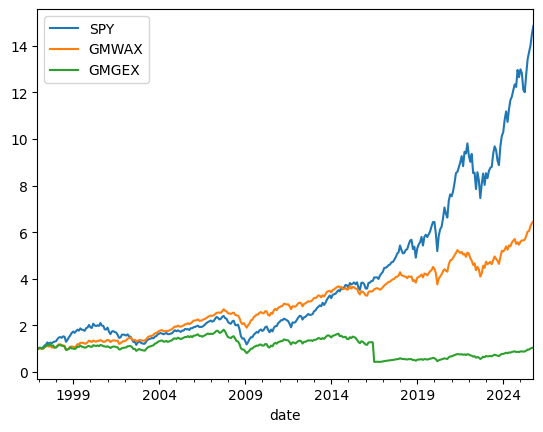

In [52]:
(1 + df_returns).cumprod().plot()

## 2. Tail Risk (GMWAX)

For all three samples, analyze extreme scenarios:

- minimum return  
- 5th percentile (VaR-5th)  
- maximum drawdown (compute on **total** returns, not excess returns)

**Questions:**

a) Does GMWAX have high or low tail-risk as seen by these stats?

__GMAWX has lower tail-risk than S&P. In the entire sample and in both subsamples it has less negative metrics__

b) Does that vary much across the two subsamples?

__Its tail risk statistics are marginally reduced in the last sample__

In [53]:
display(df_statistics[["min", "Var (0.05)", "CVar (0.05)", "max drawdown"]].round(2))

min  Var (0.05)  CVar (0.05)  max drawdown
entire_sample  SPY   -16.52       -7.44        -9.68        -50.80
               GMWAX -14.51       -4.04        -6.60        -29.36
               GMGEX -65.87       -7.52       -12.63        -76.18
inception_2011 SPY   -16.52       -7.95       -10.35        -50.80
               GMWAX -14.51       -4.40        -7.25        -29.36
               GMGEX -15.12       -7.97        -9.70        -55.56
2012_present   SPY   -12.46       -6.07        -8.31        -23.93
               GMWAX -11.50       -3.69        -5.56        -21.68
               GMGEX -65.87       -6.53       -15.11        -73.74

## 3. Market Exposure (GMWAX)

For all three samples, regress **excess returns of GMWAX** on **excess returns of SPY**.

Report:

- estimated **alpha**
- estimated **beta**
- **\( R^2 \)**

**Questions:**

- Is GMWAX a **low-beta** strategy? Has that changed since the case?  

__It is a high-beta strategy. In fact, when comparing both subsamples, we observe that the beta has increased slightly over the last decade. The R^2 has also risen marginally, indicating a modest strengthening in the strategy’s comovement with the market. However, its Beta is lower than GMGEX.__

- Does GMWAX provide **alpha**? Has that changed across subsamples?

__Yes, it provides small alphas. Before 2012, the strategy generated a positive alpha of around 2%. However, this pattern reverses after 2012, when the alpha turns negative, reaching approximately –4%, in line with the behavior observed in both periods (outperformance before 2011 and underperformance thereafter with respect of SPY).__

In [54]:
list_names = ["full_sample"]
list_factors = [["SPY"]]

info_reg, info_predict = fc.get_annualized_regression(df_excess_returns.filter(like = "GM"), 
                                                   df_excess_returns[["SPY"]], 
                                                   list_names, 
                                                   list_factors, 
                                                   n_temp)

info_reg_sample_1, info_predict_sample_1 = fc.get_annualized_regression(list_sample_returns[0].filter(like = "GM"), 
                                                   list_sample_returns[0][["SPY"]], 
                                                   ["inception_2011"], 
                                                   list_factors, 
                                                   n_temp)

info_reg_sample_2, info_predict_sample_2 = fc.get_annualized_regression(list_sample_returns[1].filter(like = "GM"), 
                                                   list_sample_returns[1][["SPY"]], 
                                                   ["2012_present"], 
                                                   list_factors, 
                                                   n_temp)

info_reg_total = pd.concat([info_reg, info_reg_sample_1, info_reg_sample_2], axis = 1)
display(info_reg_total.loc[:, (slice(None), ["Alpha", "Beta_SPY", "r_squared"])].transpose().round(4))

,,GMWAX,GMGEX
full_sample,Alpha,0.0022,-0.0608
inception_2011,Alpha,0.0400,-0.0244
2012_present,Alpha,-0.0208,-0.0956
full_sample,Beta_SPY,0.5475,0.7816
inception_2011,Beta_SPY,0.5414,0.7628
2012_present,Beta_SPY,0.5682,0.8264
full_sample,r_squared,0.6752,0.3984
inception_2011,r_squared,0.6501,0.7263
2012_present,r_squared,0.7304,0.2556


## 4. Compare to GMGEX

Repeat items **1–3** for **GMGEX**.

**Question:**  
What are the key differences between the two strategies?

__GMWAX is a diversified fund composed of bonds, equities, and other assets, while GMGEX is invested solely in equities. As a result, GMWAX benefits from greater diversification and is therefore less volatile than GMGEX, which is concentrated in a single asset class.__

__These differences also explain why GMGEX has a higher beta than GMWAX, since an all-equity portfolio naturally exhibits greater sensitivity to market movements. Nonetheless, GMWAX’s beta remains reasonably strong given its multi-asset composition.__

## 3. Forecast Regressions

This section utilizes data in `gmo_data.xlsx`.

### 1. Lagged Regression

Consider the regression with predictors lagged one period:

$$
r^{SPY}_t = \alpha^{SPY,X} + (\beta^{SPY,X})' X_{t-1} + \varepsilon^{SPY,X}_t
$$

Estimate (1) and report the $R^2$, as well as the OLS estimates for $\alpha$ and $\beta$.  
Do this for:

- $X$ as a single regressor, the **dividend–price ratio (DP)**
- $X$ as a single regressor, the **earnings–price ratio (EP)**
- $X$ with three regressors: **DP**, **EP**, and the **10-year yield**

For each, report the $R^2$.

In [173]:
df_signals_shift = df_signals.shift(1)

list_names = ["DP", "EP", "DP_EP_YLD"]
list_factors = [["SPX D/P"], ["SPX E/P"], ['SPX D/P', 'SPX E/P', 'T-Note 10YR']]

info_reg_shift, info_predict_shift = fc.get_annualized_regression(df_returns[["SPY"]], 
                                                   df_signals_shift, 
                                                   list_names, 
                                                   list_factors, 
                                                   n_temp)

just_estimates = info_predict_shift.filter(like = "Estimated")
just_estimates.columns = ['_'.join(col) for col in just_estimates.columns]

display(info_reg_shift.filter(like = "r_squared"))


,DP,EP,DP_EP_YLD
,r_squared,r_squared,r_squared
SPY,0.007263,0.004827,0.008638


### 2. Trading Strategy from Forecasts

For each of the three regressions:

- Build the forecasted SPY return:

$$
\hat{r}^{SPY}_{t+1}
$$

(forecast made using $X_t$ to predict $r^{SPY}_{t+1}$).

- Set the scale (portfolio weight):

$$
w_t = 100 \hat{r}^{SPY}_{t+1}
$$

- Strategy return:

$$
r^x_{t+1} = w_t \, r^{SPY}_{t+1}
$$

For each strategy, compute:

- mean, volatility, Sharpe  
- max drawdown  
- market **alpha**  
- market **beta**  
- market **information ratio**

In [193]:
just_estimates_weights = just_estimates*100
exercise_expected_returns = just_estimates_weights.apply(lambda x: x *  df_returns["SPY"], axis = 0).dropna()
just_estimates_annualized = st.get_annualize_metrics(exercise_expected_returns, n_temp)
display(just_estimates_annualized[["mean", "vol", "sharpe_ratio", "max drawdown"]])


,mean,vol,sharpe_ratio,max drawdown
DP_Estimated_SPY,11.184518,16.823244,66.482531,-69.86
EP_Estimated_SPY,10.612453,15.556140,68.220350,-61.68
DP_EP_YLD_Estimated_SPY,11.507458,16.706002,68.882179,-66.61


In [194]:
list_names = ["DP", "EP", "DP_EP_YLD"]
list_factors_new = [["DP_Estimated_SPY"], ["EP_Estimated_SPY"], ['DP_EP_YLD_Estimated_SPY']]

info_reg_estimations, info_predict_estimations = fc.get_annualized_regression(df_returns[["SPY"]], 
                                                   exercise_expected_returns, 
                                                   list_names, 
                                                   list_factors_new, 
                                                   n_temp)

In [195]:
display(info_reg_estimations.filter(like = "Beta_"))
display(info_reg_estimations.filter(like = "Alpha"))
display(info_reg_estimations.filter(like = "Info_ratio"))
display(info_reg_estimations.filter(like = "r_squared"))

,DP,EP,DP_EP_YLD
,Beta_DP_Estimated_SPY,Beta_EP_Estimated_SPY,Beta_DP_EP_YLD_Estimated_SPY
SPY,0.806314,0.92309,0.811526


,DP,EP,DP_EP_YLD
,Alpha,Alpha,Alpha
SPY,0.016468,0.008688,0.013264


,DP,EP,DP_EP_YLD
,Info_ratio,Info_ratio,Info_ratio
SPY,0.229321,0.160303,0.184347


,DP,EP,DP_EP_YLD
,r_squared,r_squared,r_squared
SPY,0.781093,0.875319,0.780234


<Axes: xlabel='date'>

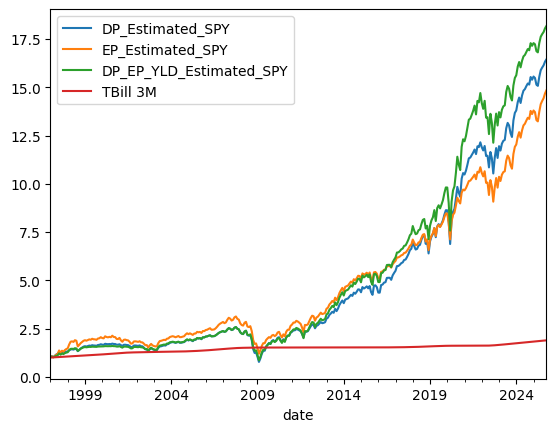

In [196]:
exercise_expected_returns = pd.merge(exercise_expected_returns, df_rfr / n_temp, how="left", left_index= True, right_index=True)
(1+exercise_expected_returns).cumprod().plot()

### 3. Risk Characteristics

- For both strategies, the market, and GMO, compute monthly **VaR** at  
  $ \pi = 0.05 $
  using the historical quantile.

- The case mentions that stocks under-performed short-term bonds from 2000–2011.  
  Does the **dynamic portfolio** above under-perform the risk-free rate over this period?

__Between 2000 and 2011, the dynamic portfolio underperformed bonds around 2009. However, for the rest of the sample period the strategy outperformed.__

- Based on the regression estimates, in how many periods do we estimate a **negative risk premium**?

__We have marginal negative risk premium in 2009__

- Do you believe the dynamic strategy takes on **extra risk**?

__No, the dynamic strategy does not take extra risk. In fact, it takes much less risk than both SPY and GMO.__

In [ ]:
exercise_expected_returns.drop(columns = ["TBill 3M"], inplace = True)
df_full_statistics = pd.concat([st.get_annualize_metrics(df_returns, n_temp), 
                                st.get_annualize_metrics(exercise_expected_returns, n_temp)], axis = 0)
df_full_statistics.drop(index = ["GMGEX"], inplace = True)
display(df_full_statistics[["mean", "vol", "sharpe_ratio", "min", "max drawdown", "Var (0.05)"]].round(2))

,mean,vol,sharpe_ratio,min,max drawdown,Var (0.05)
SPY,10.55,15.34,68.81,-16.52,-50.80,-7.44
GMWAX,7.00,10.23,68.47,-14.51,-29.36,-4.04
GMGEX,2.66,19.02,13.98,-65.87,-76.18,-7.52
DP_Estimated_SPY,11.18,16.82,66.48,-25.62,-69.86,-6.15
EP_Estimated_SPY,10.61,15.56,68.22,-19.96,-61.68,-6.41
DP_EP_YLD_Estimated_SPY,11.51,16.71,68.88,-24.32,-66.61,-6.52


## 4. Out-of-Sample Forecasting

This section utilizes data in `gmo_data.xlsx`.  
Focus on using **both** $DP$ and $EP$ as signals in (1).

Compute **out-of-sample (OOS)** statistics.

### **Procedure (rolling OOS):**

- Start at $t = 60$.
- Estimate equation (1) using data **through** time $t$.
- Using the estimated parameters and $x_t$, compute the forecast for $t+1$:

$$
\hat r^{SPY}_{t+1} 
= \hat \alpha^{SPY,X}_t 
+ \left( \hat \beta^{SPY,X}_t \right)' x_t
$$

- Forecast error:

$$
e^{forecast}_{t+1} 
= r^{SPY}_{t+1} - \hat r^{SPY}_{t+1}
$$

- Move to $t = 61$ and iterate.

### **Null forecast and errors**

Compute the null forecast:

$$
\bar r^{SPY}_{t+1}
= \frac{1}{t} \sum_{i=1}^{t} r^{SPY}_i
$$

and its error:

$$
e^{null}_{t+1} 
= r^{SPY}_{t+1} - \bar r^{SPY}_{t+1}.
$$

In [143]:
rolling_window = 60
list_names = ["model_1"]
list_factors = [["SPX D/P", "SPX E/P"]]
list_results = []
df_dependent_var = df_returns[["SPY"]]

for i in range(len(df_returns)-rolling_window-1):
    df_estimate_date = df_signals.iloc[i+rolling_window,:].name
    df_aux_signals = df_signals.iloc[i:i+rolling_window,:]
    df_aux = df_dependent_var.iloc[i:i+rolling_window,:]
    info_reg_shift, info_predict_shift = fc.get_annualized_regression(df_dependent_var, 
                                                   df_aux_signals, 
                                                   list_names, 
                                                   list_factors, 
                                                   n_temp)
    df_last_info = info_predict_shift[info_predict_shift.index == info_predict_shift.index.max()]
    df_last_info = df_last_info.filter(like = "Estimated")
    df_last_info.index = [df_estimate_date]
    df_last_info[("model_1", "Estimated_mean")] = df_aux.mean(axis = 0).item()
    list_results.append(df_last_info)

df_results = pd.concat(list_results, axis = 0)
df_results.columns = df_results.columns.droplevel()
df_results = pd.merge(df_dependent_var,df_results, how = "left", left_index= True, right_index= True)
df_results.dropna(axis = 0, inplace = True)
df_results["error_null"] = df_results["SPY"] -   df_results["Estimated_mean"]
df_results["error_forecasts"] = df_results["SPY"] -   df_results["Estimated_SPY"]
df_results

,SPY,Estimated_SPY,Estimated_mean,error_null,error_forecasts
date,,,,,
2001-12-31,0.005616,0.006041,0.009165,-0.003548,-0.000424
2002-01-31,-0.009798,0.006931,0.009647,-0.019445,-0.016729
2002-02-28,-0.017937,0.003505,0.008454,-0.026390,-0.021441
2002-03-29,0.033243,0.001828,0.007995,0.025248,0.031414
2002-04-30,-0.058155,0.005898,0.009311,-0.067467,-0.064053
...,...,...,...,...,...
2025-05-30,0.062845,0.010412,0.013133,0.049712,0.052433
2025-06-30,0.051394,0.016012,0.013386,0.038007,0.035382
2025-07-31,0.023031,0.021168,0.013947,0.009085,0.001863


### 1. Report the out-of-sample \( R^2 \)

The out-of-sample \( R^2 \) is defined as:

$$
R^2_{OOS}
\equiv
1 - 
\frac{
\sum_{i=61}^{T} \left( e^{\text{forecast}}_i \right)^2
}{
\sum_{i=61}^{T} \left( e^{\text{null}}_i \right)^2
}
$$

Did this forecasting strategy produce a **positive** $R^2_{OOS}$?

__No__

In [148]:
1 - (df_results["error_forecasts"] ** 2).sum() / (df_results["error_null"] ** 2).sum()

np.float64(-0.252314773751553)

### 2. Redo 3.2 with OOS forecasts  
How does the OOS strategy compare to the **in-sample** version of 3.2?

In [215]:
rolling_window = 60
list_names = ["model_2"]
list_factors = [["SPX D/P", "SPX E/P"]]
list_results = []
df_dependent_var = df_returns[["SPY"]]

for i in range(len(df_returns)-rolling_window-1):
    df_estimate_date = df_signals.iloc[i+rolling_window,:].name
    df_aux_signals = df_signals.iloc[i:i+rolling_window,:]
    df_aux = df_dependent_var.iloc[i:i+rolling_window,:]
    info_reg_shift, info_predict_shift = fc.get_annualized_regression(df_dependent_var, 
                                                   df_aux_signals, 
                                                   list_names, 
                                                   list_factors, 
                                                   n_temp)
    just_estimated_shift = info_predict_shift.filter(like = "Estimated")
    just_estimated_shift.columns = just_estimated_shift.columns.droplevel(0)
    df_last_info = pd.DataFrame([just_estimated_shift.iloc[-1,:].item()], index = [df_estimate_date], columns = ["weights"])
    #df_last_info = info_predict_shift[info_predict_shift.index == info_predict_shift.index.max()]
    #df_last_info = df_last_info.filter(like = "Estimated")
    #df_last_info.index = [df_estimate_date]
    df_last_info["Estimated_mean"] = df_aux.mean(axis = 0).item()
    list_results.append(df_last_info)

df_results = pd.concat(list_results, axis = 0)
df_results *= 100
df_results = pd.merge(df_results,df_dependent_var, how = "left", left_index= True, right_index= True)
df_results["Forecast"] = df_results["weights"] * df_results["SPY"]
df_results["error_null"] = df_results["SPY"] -   df_results["Estimated_mean"]
df_results["error_forecasts"] = df_results["SPY"] -   df_results["Forecast"]
df_results

,weights,Estimated_mean,SPY,Forecast,error_null,error_forecasts
2001-12-31,0.604075,0.916494,0.005616,0.003393,-0.910877,0.002224
2002-01-31,0.693053,0.964675,-0.009798,-0.006791,-0.974473,-0.003008
2002-02-28,0.350452,0.845367,-0.017937,-0.006286,-0.863303,-0.011651
2002-03-29,0.182840,0.799530,0.033243,0.006078,-0.766287,0.027165
2002-04-30,0.589797,0.931137,-0.058155,-0.034300,-0.989292,-0.023855
...,...,...,...,...,...,...
2025-05-30,1.041167,1.313300,0.062845,0.065432,-1.250455,-0.002587
2025-06-30,1.601158,1.338633,0.051394,0.082290,-1.287239,-0.030896
2025-07-31,2.116822,1.394687,0.023031,0.048754,-1.371656,-0.025722
2025-08-29,2.460050,1.334919,0.020520,0.050479,-1.314400,-0.029960


In [216]:
1 - (df_results["error_forecasts"] ** 2).sum() / (df_results["error_null"] ** 2).sum()

np.float64(0.9687597107367758)

### 3. Redo 3.3 with OOS forecasts  
Is the point-in-time version of the strategy **riskier**?

__The in-sample dynamic strategies (DP, EP, DP+EP) show reasonable performance that roughly matches the SPY benchmark.__
__However, when we compute the strategy out-of-sample, the performance deteriorates substantially.__
__The OOS volatility explodes, Sharpe ratio collapses, and drawdowns increase dramatically.__
__This indicates that the weak predictive power of DP and EP does not survive out-of-sample evaluation.__

In [218]:
df_full_statistics_part2 = pd.concat([df_full_statistics, 
                                st.get_annualize_metrics(df_results[["Forecast"]], n_temp)], axis = 0)
display(df_full_statistics_part2[["mean", "vol", "sharpe_ratio", "min", "max drawdown", "Var (0.05)"]].round(2))

,mean,vol,sharpe_ratio,min,max drawdown,Var (0.05)
SPY,10.55,15.34,68.81,-16.52,-50.80,-7.44
GMWAX,7.00,10.23,68.47,-14.51,-29.36,-4.04
GMGEX,2.66,19.02,13.98,-65.87,-76.18,-7.52
DP_Estimated_SPY,11.18,16.82,66.48,-25.62,-69.86,-6.15
EP_Estimated_SPY,10.61,15.56,68.22,-19.96,-61.68,-6.41
DP_EP_YLD_Estimated_SPY,11.51,16.71,68.88,-24.32,-66.61,-6.52
Forecast,9.12,49.57,18.40,-92.46,-99.14,-15.61
